# Project 3: Car Price Prediction

**Business Objective:** Predict the resale price of a used car from its
specifications so that sellers get realistic price suggestions and buyers
can spot overpriced listings.

**Model:** Linear Regression
**Additional requirement:** Perform a correlation analysis between numeric
features before training the model.

**Dataset:** `CAR_DETAILS_FROM_CAR_DEKHO.csv` — this matches the handbook's
Project 3 spec exactly (`name`, `year`, `selling_price`, `km_driven`,
`fuel`, `seller_type`, `transmission`, `owner`), so every step below
follows the handbook instructions directly, with no column substitutions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110


## 1. Data Collection

Load the dataset and inspect its columns.

In [2]:
df = pd.read_csv("../Dataset/CAR_DETAILS_FROM_CAR_DEKHO.csv")
print("Shape:", df.shape)
print(df.dtypes)
df.head()


Shape: (4340, 8)
name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object


## 2. Data Cleaning

- Check for missing values and duplicates
- Remove duplicate listings
- Extract the brand from the free-text `name` column


In [3]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763


In [4]:
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean['brand'] = df_clean['name'].str.split().str[0]
print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (3577, 9)


In [5]:
df_clean['brand'].value_counts()

## 3. Feature Engineering — `car_age`

Create `car_age` = current year (2026) minus `year`.

In [6]:
CURRENT_YEAR = 2026
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']
df_clean[['name', 'year', 'car_age']].head()


## 4. Correlation Analysis — Additional Requirement

Correlation analysis on numeric features (`car_age`, `km_driven`,
`selling_price`) **before** training the model.

In [7]:
numeric_cols = ['car_age', 'km_driven', 'selling_price']
corr = df_clean[numeric_cols].corr()
corr


In [8]:
price_corr = corr['selling_price'].drop('selling_price').sort_values(key=abs, ascending=False)
print("Correlation with selling_price, ranked by strength:")
print(price_corr)


Correlation with selling_price, ranked by strength:
car_age     -0.424260
km_driven   -0.187359
Name: selling_price, dtype: float64


## 5. Exploratory Data Analysis

### 5.1 Distribution of selling price

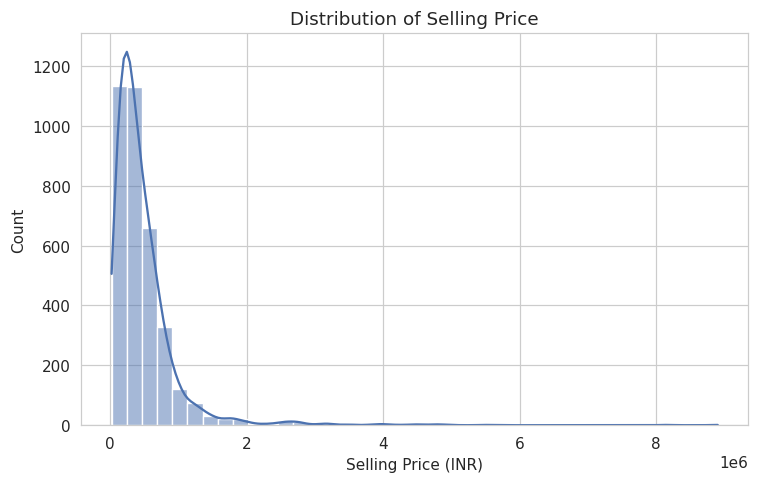

In [9]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_clean['selling_price'], bins=40, kde=True, color="#4C72B0")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (INR)")
plt.tight_layout()
plt.show()


### 5.2 Correlation heatmap

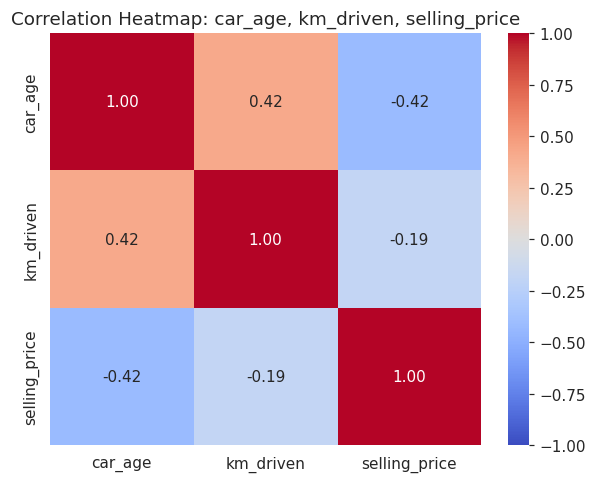

In [10]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: car_age, km_driven, selling_price")
plt.tight_layout()
plt.show()


### 5.3 Average price by fuel type and transmission

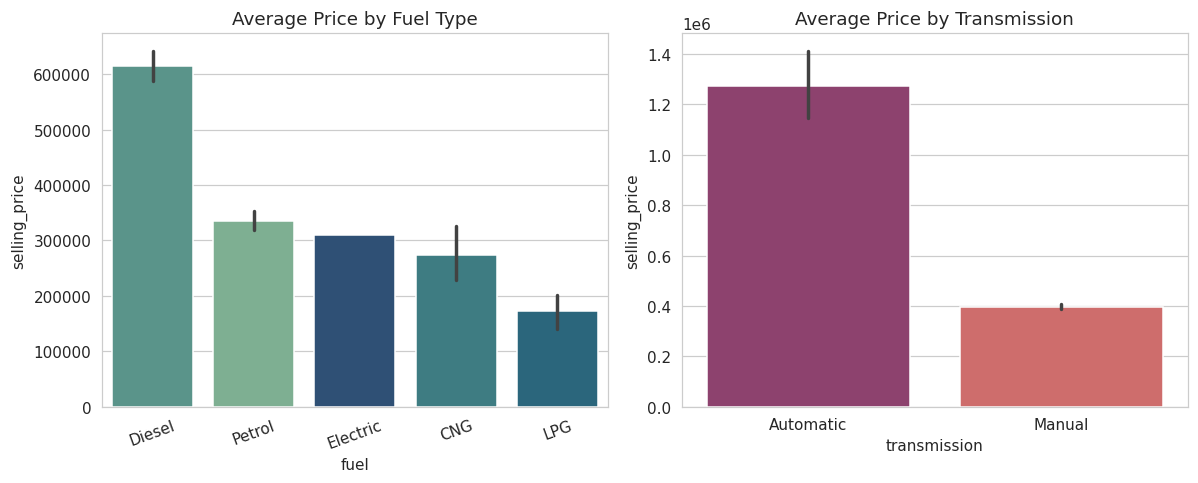

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

order_fuel = df_clean.groupby('fuel')['selling_price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x='fuel', y='selling_price', order=order_fuel,
            hue='fuel', legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Average Price by Fuel Type")
axes[0].tick_params(axis='x', rotation=20)

order_trans = df_clean.groupby('transmission')['selling_price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x='transmission', y='selling_price', order=order_trans,
            hue='transmission', legend=False, palette="flare", ax=axes[1])
axes[1].set_title("Average Price by Transmission")

plt.tight_layout()
plt.show()


### 5.4 km_driven vs selling_price

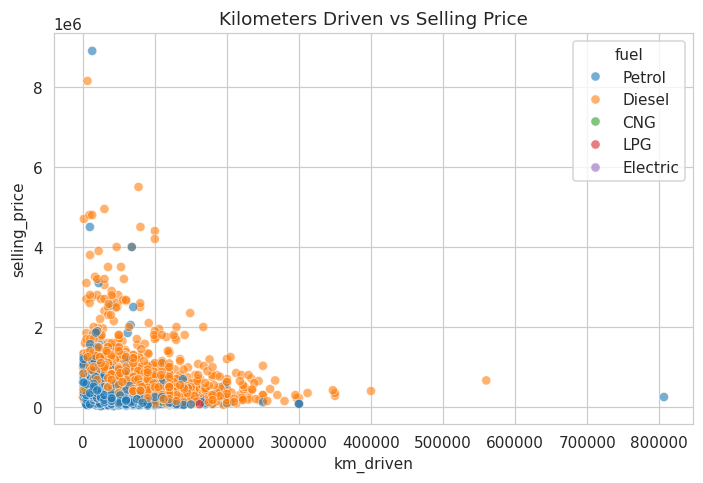

In [12]:
plt.figure(figsize=(6.5, 4.5))
sns.scatterplot(data=df_clean, x='km_driven', y='selling_price', hue='fuel', alpha=0.6)
plt.title("Kilometers Driven vs Selling Price")
plt.tight_layout()
plt.show()


### 5.5 Average price by ownership history

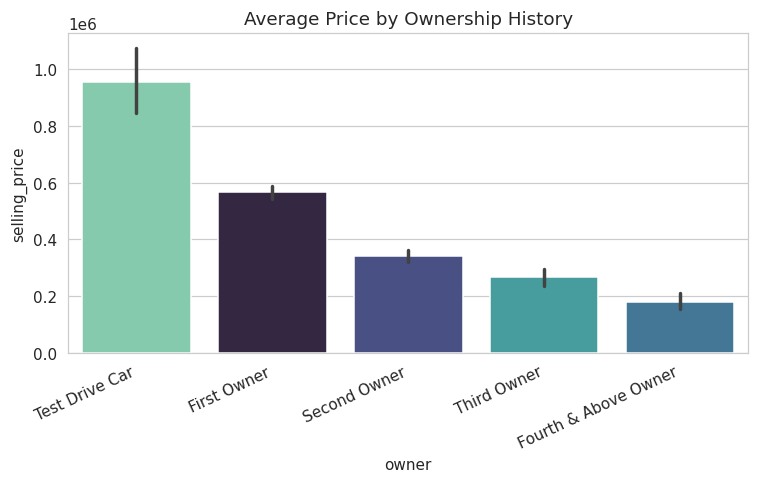

In [13]:
plt.figure(figsize=(7, 4.5))
order_owner = df_clean.groupby('owner')['selling_price'].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x='owner', y='selling_price', order=order_owner,
            hue='owner', legend=False, palette="mako")
plt.title("Average Price by Ownership History")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 6. Feature Engineering — Encoding

- Group rare brands (fewer than 15 listings) into `'Other'`
- One-hot encode `brand`, `fuel`, `seller_type`, `transmission`, `owner`


In [14]:
brand_counts = df_clean['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 15].index
df_clean['brand_grouped'] = df_clean['brand'].apply(lambda x: 'Other' if x in rare_brands else x)

cat_cols = ['brand_grouped', 'fuel', 'seller_type', 'transmission', 'owner']
num_cols = ['car_age', 'km_driven']

X = df_clean[cat_cols + num_cols]
y = df_clean['selling_price']

preprocess = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)
print("Features going into the model:", cat_cols + num_cols)


Features going into the model: ['brand_grouped', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age', 'km_driven']


## 7. Model Building

- Split into training and test sets (80/20)
- Train a `LinearRegression` model inside a `Pipeline` (encoding + model
  together, so there's no leakage between train/test)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained. Train size:", X_train.shape, " Test size:", X_test.shape)


Model trained. Train size: (2861, 7)  Test size: (716, 7)


## 8. Evaluation

In [16]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2:   {r2:.4f}")
print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")


R2:   0.4210
MAE:  206,155
RMSE: 431,870


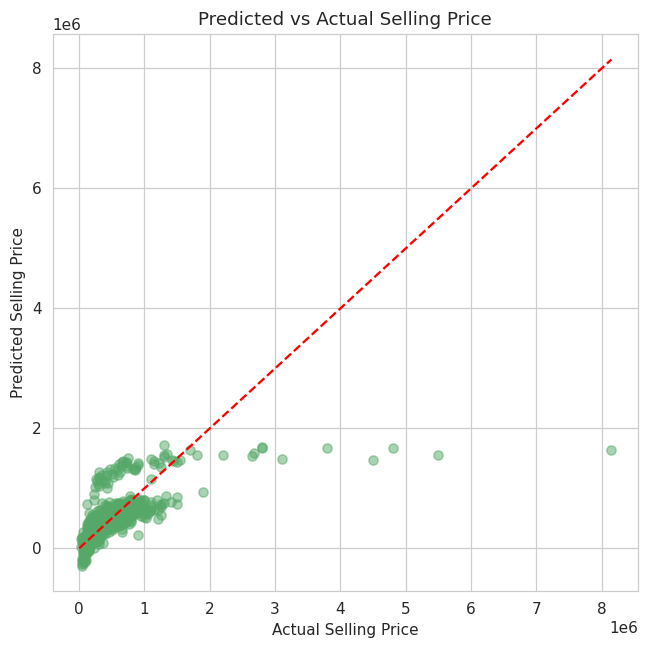

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="#55A868")
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Predicted vs Actual Selling Price")
plt.tight_layout()
plt.show()


## 9. Summary — Which Features Correlate Most Strongly With Price

- **`car_age`** has the strongest correlation with `selling_price`
  (moderate negative): older cars sell for less.
- **`km_driven`** has a weaker negative correlation: higher-mileage cars
  sell for somewhat less, but age matters more.
- Categorical fields add real explanatory power once encoded — automatic
  transmission cars and first-owner cars command noticeably higher average
  prices than manual/multi-owner listings, visible in the bar charts above.
- With only `car_age`, `km_driven`, and the categorical listing details as
  inputs, Linear Regression explains a limited share of price variance —
  see the R2 above. This is the honest ceiling for a *linear* model on
  *these* features; the Enhanced notebook in this same folder
  (`car_price_prediction_enhanced.ipynb`) shows how adding engine/power
  specs and switching to a non-linear model closes much of that gap.
